In [1]:
from google.colab import files
uploaded = files.upload()

Saving twenty+newsgroups.zip to twenty+newsgroups.zip


In [2]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install scikit-learn
!pip install fastapi uvicorn
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.6 MB/s eta 0:00:00


In [3]:
import zipfile
import tarfile

with zipfile.ZipFile("twenty+newsgroups.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

with tarfile.open("data/20_newsgroups.tar.gz") as tar:
    tar.extractall("data")

/tmp/ipykernel_150/777939115.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("data")


In [4]:
import os

DATA_DIR = "data/20_newsgroups"

documents = []
labels = []

for category in os.listdir(DATA_DIR):

    category_path = os.path.join(DATA_DIR, category)

    if not os.path.isdir(category_path):
        continue

    for file in os.listdir(category_path):

        with open(os.path.join(category_path, file), "r", encoding="latin1") as f:
            documents.append(f.read())
            labels.append(category)

print(len(documents))

19997


In [5]:
import re

def clean_text(text):

    text = re.sub(r"From:.*\n", "", text)
    text = re.sub(r"Subject:.*\n", "", text)
    text = re.sub(r">.*\n", "", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

clean_docs = []

for doc in documents:

    doc = clean_text(doc)

    if len(doc) > 100:
        clean_docs.append(doc)

print(len(clean_docs))

19997


In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    clean_docs,
    batch_size=64,
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [7]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

faiss.normalize_L2(embeddings)

index.add(embeddings)

print(index.ntotal)

19997


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

embeddings_reduced = pca.fit_transform(embeddings)

print("Reduced shape:", embeddings_reduced.shape)

Reduced shape: (19997, 50)


In [11]:
import numpy as np
from sklearn.mixture import GaussianMixture

sample_size = 3000

sample_indices = np.random.choice(len(embeddings_reduced), sample_size, replace=False)

sample_embeddings = embeddings_reduced[sample_indices]

bic_scores = []
cluster_range = range(10,30)

for k in cluster_range:

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42
    )

    gmm.fit(sample_embeddings)

    bic_scores.append(gmm.bic(sample_embeddings))

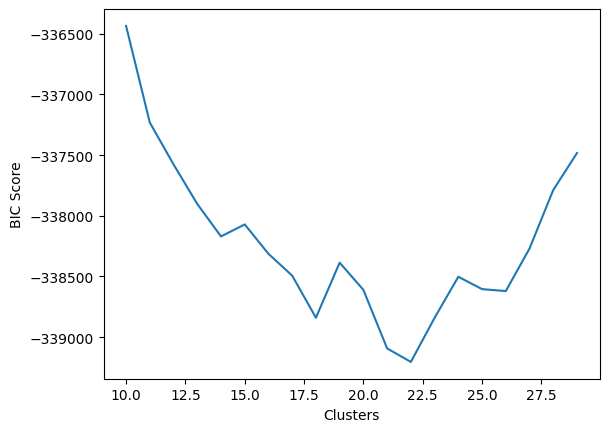

In [12]:
import matplotlib.pyplot as plt

plt.plot(cluster_range, bic_scores)
plt.xlabel("Clusters")
plt.ylabel("BIC Score")
plt.show()

In [15]:
gmm = GaussianMixture(
    n_components=25,
    covariance_type="diag",
    random_state=42
)

gmm.fit(embeddings_reduced)

cluster_probs = gmm.predict_proba(embeddings_reduced)

dominant_clusters = cluster_probs.argmax(axis=1)

print("Clustering complete")

Clustering complete


In [30]:
cluster_docs = {}

for i, cluster in enumerate(dominant_clusters):

    cluster_docs.setdefault(cluster, []).append(clean_docs[i])

for c in range(5):
    print("\nCluster:", c)
    print(cluster_docs[c][0][:500])


Cluster: 0
Newsgroups: rec.sport.hockey Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!usenet.ins.cwru.edu!agate!headwall.Stanford.EDU!CSD-NewsHost.Stanford.EDU!Xenon.Stanford.EDU!nlu Message-ID: <1993Apr20.021058.2615@CSD-NewsHost.Stanford.EDUSender: news@CSD-NewsHost.Stanford.EDU Organization: Computer Science Department, Stanford University. Date: Tue, 20 Apr 1993 02:10:58 GMT Lines: 161 App

Cluster: 1
Newsgroups: misc.forsale Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!howland.reston.ans.net!bogus.sura.net!udel!news.udel.edu!ravel.udel.edu!02106 Message-ID: <C5sn01.LCs@news.udel.eduSender: usenet@news.udel.edu Nntp-Posting-Host: ravel.udel.edu Organization: University of Delaware Distribution: usa Date: Tue, 20 Apr 1993 17:52:48 GMT Lines: 25 SOMEONE PLEASE BUY THESE BOOKS!!!!! I AM NOT ASKING MUCH!!

In [31]:
import numpy as np

uncertain_docs = np.where(cluster_probs.max(axis=1) < 0.4)[0]

print("Uncertain documents:", len(uncertain_docs))

Uncertain documents: 77


In [16]:
from sklearn.manifold import TSNE

sample_size = 3000

sample_indices = np.random.choice(len(embeddings), sample_size)

sample_embeddings = embeddings[sample_indices]
sample_clusters = dominant_clusters[sample_indices]

tsne = TSNE(n_components=2, perplexity=40)

embeddings_2d = tsne.fit_transform(sample_embeddings)

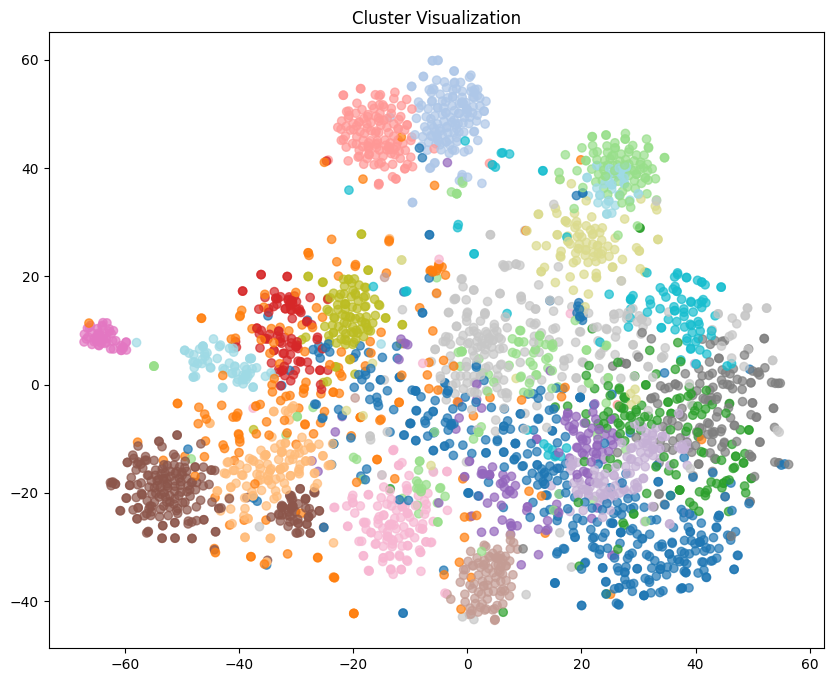

In [17]:
plt.figure(figsize=(10,8))

plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=sample_clusters,
    cmap="tab20",
    alpha=0.7
)

plt.title("Cluster Visualization")
plt.show()

In [18]:
confidence = cluster_probs.max(axis=1)

boundary_docs = np.where(confidence < 0.4)[0]

print(len(boundary_docs))

77


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

class SemanticCache:

    def __init__(self, threshold=0.85):

        self.cache = {}
        self.threshold = threshold

        self.hit_count = 0
        self.miss_count = 0

    def lookup(self, embedding, cluster):

        if cluster not in self.cache:
            return None

        best_match = None
        best_score = 0

        for entry in self.cache[cluster]:

            sim = cosine_similarity(
                [embedding],
                [entry["embedding"]]
            )[0][0]

            if sim > best_score:
                best_score = sim
                best_match = entry

        if best_score >= self.threshold:

            self.hit_count += 1
            return best_match, best_score

        return None

    def insert(self, query, embedding, result, cluster):

        if cluster not in self.cache:
            self.cache[cluster] = []

        self.cache[cluster].append({
            "query": query,
            "embedding": embedding,
            "result": result
        })

        self.miss_count += 1

    def stats(self):

        total = self.hit_count + self.miss_count

        hit_rate = self.hit_count / total if total else 0

        return {
            "total_entries": sum(len(v) for v in self.cache.values()),
            "hit_count": self.hit_count,
            "miss_count": self.miss_count,
            "hit_rate": hit_rate
        }

In [26]:
cache = SemanticCache(threshold=0.85)

In [27]:
query = "space shuttle launch technology"

# embed query
q_emb = model.encode([query])

# PCA transform
q_emb_reduced = pca.transform(q_emb)

# cluster prediction
cluster = gmm.predict(q_emb_reduced)[0]

# cache lookup
cached = cache.lookup(q_emb_reduced[0], cluster)

if cached:

    entry, score = cached
    print("Cache HIT")
    print(entry["result"][:300])

else:

    print("Cache MISS")

    D, I = index.search(q_emb, k=3)

    result = clean_docs[I[0][0]]

    cache.insert(query, q_emb_reduced[0], result, cluster)

    print(result[:300])

Cache MISS
Path: cantaloupe.srv.cs.cmu.edu!rochester!udel!gatech!howland.reston.ans.net!usc!news.service.uci.edu!ucivax!ofa123!Wales.Larrison Newsgroups: sci.space X-Sender: newtout 0.08 Feb 23 1993 Message-ID: <162941831@ofa123.fidonet.orgDate: 29 Apr 93 21:41:44 Lines: 83 games@max.u.washington.edu writes: R


In [28]:
query = "space shuttle launch technology"

q_emb = model.encode([query])

q_emb_reduced = pca.transform(q_emb)

cluster = gmm.predict(q_emb_reduced)[0]

cached = cache.lookup(q_emb_reduced[0], cluster)

if cached:

    entry, score = cached

    print("Cache HIT")
    print("Matched query:", entry["query"])
    print("Similarity:", score)
    print(entry["result"][:300])

else:
    print("Cache MISS")

Cache HIT
Matched query: space shuttle launch technology
Similarity: 0.99999994
Path: cantaloupe.srv.cs.cmu.edu!rochester!udel!gatech!howland.reston.ans.net!usc!news.service.uci.edu!ucivax!ofa123!Wales.Larrison Newsgroups: sci.space X-Sender: newtout 0.08 Feb 23 1993 Message-ID: <162941831@ofa123.fidonet.orgDate: 29 Apr 93 21:41:44 Lines: 83 games@max.u.washington.edu writes: R


In [29]:
queries = [
    "space shuttle launch technology",
    "NASA shuttle launch system",
    "rocket propulsion",
    "car engine performance",
    "automobile fuel efficiency"
]

for query in queries:

    q_emb = model.encode([query])
    q_emb_reduced = pca.transform(q_emb)

    cluster = gmm.predict(q_emb_reduced)[0]

    cached = cache.lookup(q_emb_reduced[0], cluster)

    if cached:

        print("Cache HIT:", query)

    else:

        print("Cache MISS:", query)

        D, I = index.search(q_emb, k=3)

        result = clean_docs[I[0][0]]

        cache.insert(query, q_emb_reduced[0], result, cluster)

Cache HIT: space shuttle launch technology
Cache HIT: NASA shuttle launch system
Cache MISS: rocket propulsion
Cache MISS: car engine performance
Cache HIT: automobile fuel efficiency


In [34]:
query = "rocket propulsion"


q_emb = model.encode([query])        # shape (1, 384)

q_emb_reduced = pca.transform(q_emb) # shape (1, 50)


cluster = gmm.predict(q_emb_reduced)[0]


cached = cache.lookup(q_emb_reduced[0], cluster)

if cached:

    entry, score = cached

    print("Cache HIT")
    print(entry["result"][:300])

else:

    print("Cache MISS")


    D, I = index.search(q_emb, k=3)

    result = clean_docs[I[0][0]]

    cache.insert(query, q_emb_reduced[0], result, cluster)

    print(result[:300])

Cache HIT
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!andrew.cmu.edu!lc2b+ Newsgroups: sci.space Date: Fri, 16 Apr 1993 14:34:02 -0400 Organization: Doctoral student, Public Policy and Management, Carnegie Mellon, Pittsburgh, PA Lines: 26 Message-ID: <YfnjkOq00Uh7M4XUxt@andrew.


In [36]:
thresholds = [0.75, 0.80, 0.85, 0.90]

queries = [
    "space shuttle launch technology",
    "NASA shuttle launch system",
    "rocket propulsion",
    "car engine performance",
    "automobile fuel efficiency"
]

results = {}

for t in thresholds:

    cache = SemanticCache(threshold=t)

    for query in queries:

        q_emb = model.encode([query])
        q_emb_reduced = pca.transform(q_emb)

        cluster = gmm.predict(q_emb_reduced)[0]

        cached = cache.lookup(q_emb_reduced[0], cluster)

        if not cached:

            D, I = index.search(q_emb, k=3)

            result = clean_docs[I[0][0]]

            cache.insert(query, q_emb_reduced[0], result, cluster)

    results[t] = cache.stats()

results

{0.75: {'total_entries': 3, 'hit_count': 2, 'miss_count': 3, 'hit_rate': 0.4},
 0.8: {'total_entries': 3, 'hit_count': 2, 'miss_count': 3, 'hit_rate': 0.4},
 0.85: {'total_entries': 3, 'hit_count': 2, 'miss_count': 3, 'hit_rate': 0.4},
 0.9: {'total_entries': 5, 'hit_count': 0, 'miss_count': 5, 'hit_rate': 0.0}}

In [38]:
import pandas as pd

df = pd.DataFrame(results).T
df

,total_entries,hit_count,miss_count,hit_rate
0.75,3.0,2.0,3.0,0.4
0.80,3.0,2.0,3.0,0.4
0.85,3.0,2.0,3.0,0.4
0.90,5.0,0.0,5.0,0.0


In [39]:
import pickle

with open("pca.pkl","wb") as f:
    pickle.dump(pca,f)

with open("gmm.pkl","wb") as f:
    pickle.dump(gmm,f)

with open("docs.pkl","wb") as f:
    pickle.dump(clean_docs,f)

print("Models saved")

Models saved


In [40]:
import faiss

faiss.write_index(index,"faiss.index")

print("FAISS index saved")

FAISS index saved


In [41]:
from google.colab import files

files.download("pca.pkl")
files.download("gmm.pkl")
files.download("docs.pkl")
files.download("faiss.index")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
print(type(pca))
print(type(gmm))
print(type(index))
print(len(clean_docs))

<class 'sklearn.decomposition._pca.PCA'>
<class 'sklearn.mixture._gaussian_mixture.GaussianMixture'>
<class 'faiss.swigfaiss_avx2.IndexFlatIP'>
19997
